In [100]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Membaca citra yang akan di olah


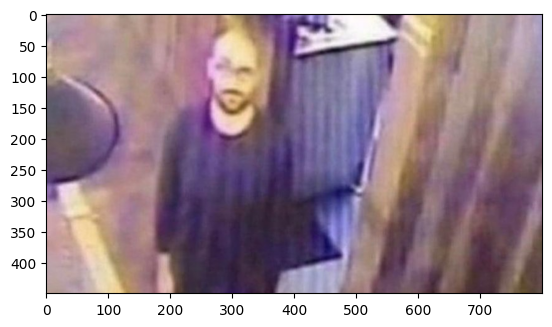

In [101]:
cctv = cv.imread("backup.jpg")

plt.imshow(cv.cvtColor(cctv, cv.COLOR_BGR2RGB))

### Mengubah citra menjadi grayscale

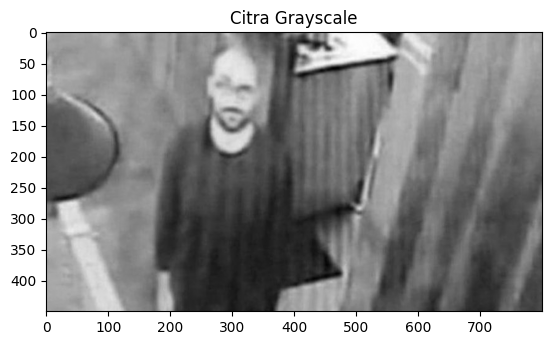

In [102]:
cctv_gray = cv.cvtColor(cctv, cv.COLOR_BGR2GRAY)

plt.title("Citra Grayscale")
plt.imshow(cctv_gray, cmap = "gray")

In [103]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2

    # Padding manual
    padded = np.zeros((height + 2*pad, width + 2*pad), dtype=img.dtype)
    padded[pad:pad+height, pad:pad+width] = img

    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for r in range(size):
                        for c in range(size):
                            total += int(region[r, c])
                    canvas[i, j] = total // area

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    # rumus median manual
                    values = sorted(values)
                    canvas[i, j] = values[len(values) // 2]

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    # hitung kemunculan
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas

### Fungsi filter
fungsi filter ini digunakan untuk memproses citra sesuai ukuran dan metode yang mau digunakan yaitu mean, median, dan modus.

In [104]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    
    # Padding nol manual
    height, width = img.shape
    padded = np.zeros((height + 2*pad_size, width + 2*pad_size), dtype=np.float32)
    padded[pad_size:pad_size+height, pad_size:pad_size+width] = img
    
    canvas = np.zeros_like(img, dtype=np.float32)
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    
    return canvas

## fungsi Konvolusi
Fungsi ini digunakan untuk menerapkan konvolusi citra dengan kernel kernel seperti sobel, roberts, dan perwitt. Fungsi ini juga akan digunakan saat melakuakn deteksi tepi atau edge detect untuk melihat suatu objek di citra

In [105]:
# Kernel smoothing (menghaluskan)
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

# Kernel sharpening (mempertajam)
kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

## Kernel Sharping dan Smoothing
kernel ini digunakan saat melakukan konvolusi citra jika ingin di muluskan atau di tajamkan

In [106]:
# Sobel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

# Prewitt
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

# Roberts
robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

### Kernel Operator
sesuai namanya kernel di atas merupakan kernel yang akan digunakan untuk melakukan konvolusi terhadap citra

In [107]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    
    canvas = np.zeros_like(img, dtype=np.float32)
    
    # Gabung gradien absolut
    canvas = np.abs(gx) + np.abs(gy)
    
    # Normalisasi ke 0-255
    canvas = canvas * 255.0 / np.max(canvas)
    
    return np.clip(canvas, 0, 255).astype(np.uint8)

## Fungsi edge
Fungsi ini digunakan untuk mendeteksi tepi suatu citra dengan menggunakan kernel yang telah di siapkan sebelumnya.

In [108]:
def tambah (citra1, citra2):
    return citra1 + citra2


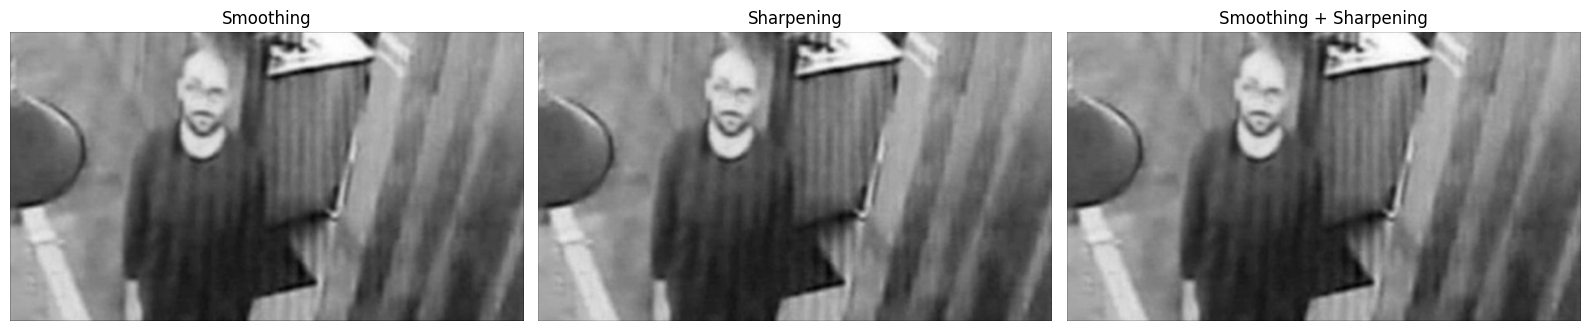

In [109]:
smooth = convolution(cctv_gray.astype(np.float32), kernelSmoothing)
sharp = convolution(cctv_gray.astype(np.float32), kernelSharpening)
smothsharp = tambah(smooth, sharp)

plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(smooth, cmap='gray')
plt.title("Smoothing")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharp, cmap='gray')
plt.title("Sharpening")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smothsharp, cmap='gray')
plt.title("Smoothing + Sharpening")
plt.axis('off')

plt.tight_layout()

### Penerapan Smoothing dan Sharpening
Menurut saya perbedaan antara ketiganya adalah. Smoothing itu dia lebih halus gitu atau agak blur, bisa dibilang warna gambarnya lebih terang atau lebih putih gitu, karena setiap piksel di bagi dengan nilai yang cukup besar. Sharpening agak sedikit lebih tajam atau lebih gelap, karena kernel membagi setiap citra piksel dengan nilai yang cukup kecil, jadinya objeknya lebih terlihat gitu, walaupun citranya terlihat sama, jika di lihat llebih teliti keliatan kok bedanya. Untuk gabungan kedunya gambarnya sedikit lebih halus/blur tapi warna atau objeknya lebih tajam.

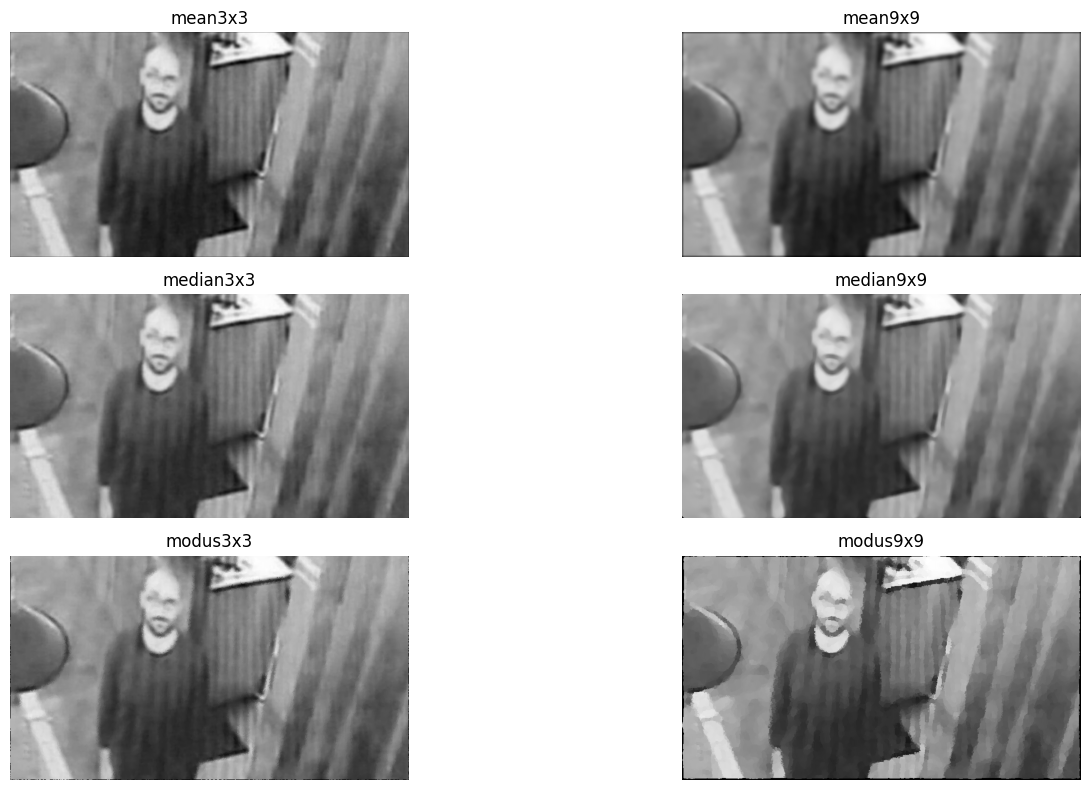

In [110]:
mean3 = filter(cctv_gray, 3, 'mean')
mean9 = filter(cctv_gray, 9, 'mean')
median3 = filter(cctv_gray, 3, 'median')
median9 = filter(cctv_gray, 9, 'median')
modus3 = filter(cctv_gray, 3, 'modus')
modus9 = filter(cctv_gray, 9, 'modus')

plt.figure(figsize=(16, 8))

plt.subplot(3, 2, 1)
plt.imshow(smooth, cmap='gray')
plt.title("mean3x3")
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(mean9, cmap='gray')
plt.title("mean9x9")
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(median3, cmap='gray')
plt.title("median3x3")
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(median9, cmap='gray')
plt.title("median9x9")
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(modus3, cmap='gray')
plt.title("modus3x3")
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(modus9, cmap='gray')
plt.title("modus9x9")
plt.axis('off')

plt.tight_layout()

### Mean
mean yang 3x3 dan 9x9 berbeda dimana yang 9x9 lebih ngeblur atau noise karena ukurannya yang berbeda, dimana ukuran piksel di mean itu bergantung dengan ukuran yang di berikan, jadi ukuran pikselnya akan di perbedar yang membuat gambarnya lebih nge blur

### Median
Median 9x9 lebih ngeblur karena menurut saya di citra ini warna putih berada di tengah, yang membuatt nilai nilai piksel lainnya berwarna lebih putih jadi agak nge blur gitu

### Modus
modus 3x3 dan 9x9 berbeda jika di lihat dari citra yang dihasilkan, 9x9 terdapat bingkai di samping citra yang lebih besar, karena ukuran nya yang lebih besar. Karena modus itu dia mengabaikan nilai nilai pinggirannya


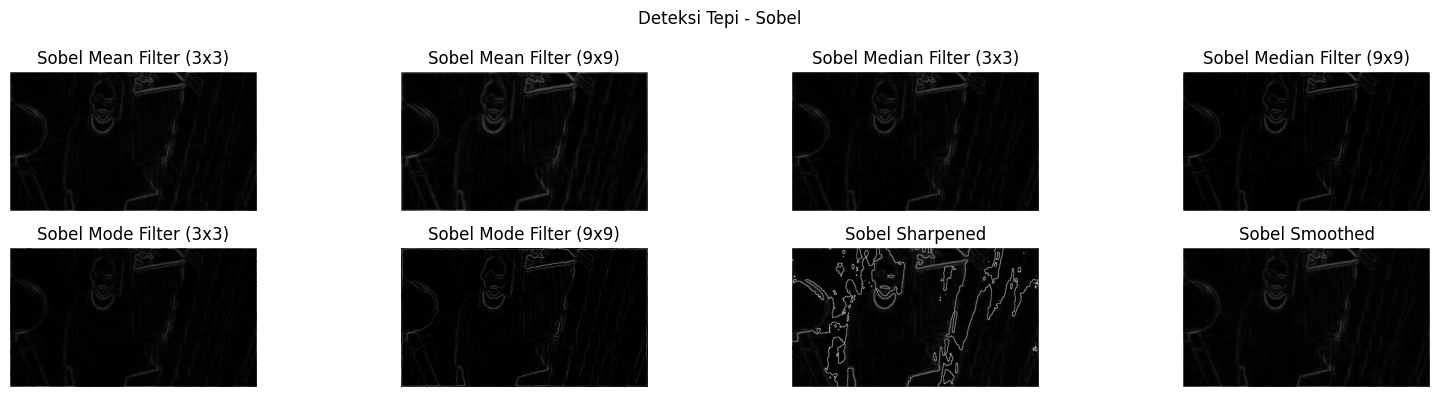

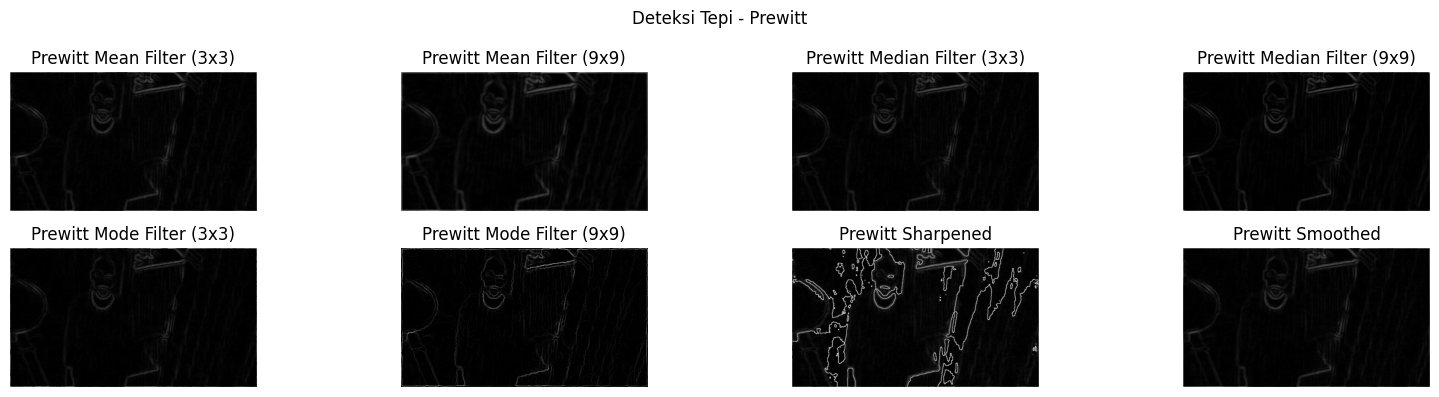

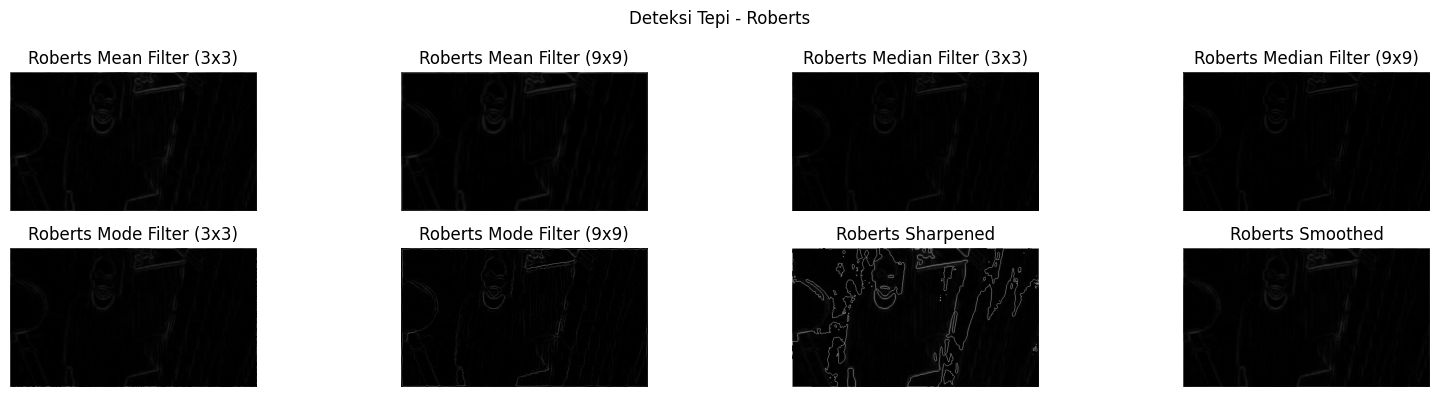

In [111]:
filtered_imgs = {
    'Mean Filter (3x3)': mean3,   'Mean Filter (9x9)': mean9,
    'Median Filter (3x3)': median3, 'Median Filter (9x9)': median9,
    'Mode Filter (3x3)': modus3,  'Mode Filter (9x9)': modus9,
    'Sharpened': sharp.astype(np.uint8),
    'Smoothed': smooth.astype(np.uint8)
}

for detector_name, (kx, ky) in [('Sobel', (sobelX, sobelY)),
                                  ('Prewitt', (prewittX, prewittY)),
                                  ('Roberts', (robertsX, robertsY))]:
    plt.figure(figsize=(16, 4))
    plt.suptitle(f'Deteksi Tepi - {detector_name}')
    for i, (title, img_f) in enumerate(filtered_imgs.items()):
        hasil_tepi = edge(img_f, kx, ky)
        plt.subplot(2, 4, i+1)
        plt.imshow(hasil_tepi, cmap='gray')
        plt.title(f'{detector_name} {title}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

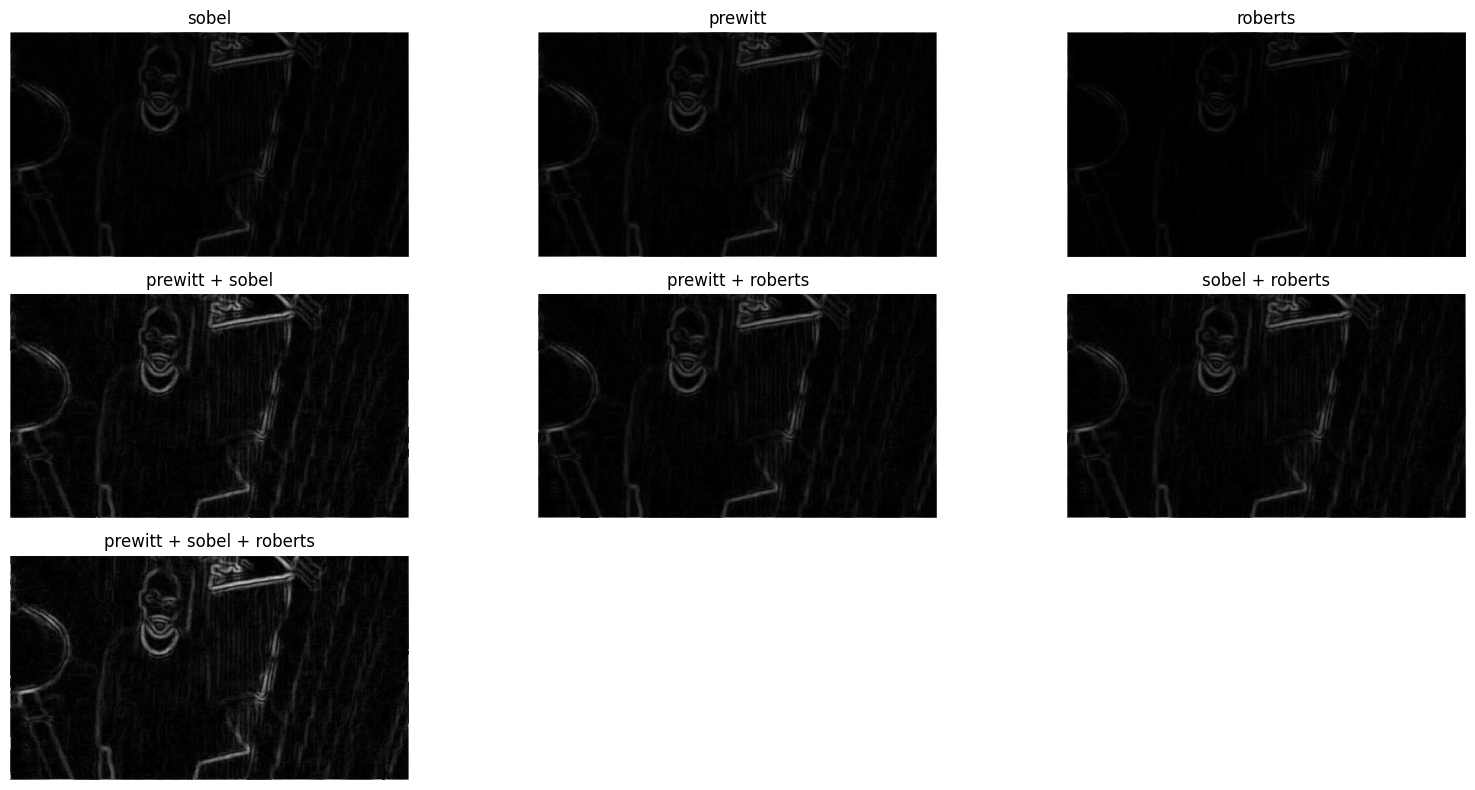

In [ ]:
sobel = edge(sharp, sobelX, sobelY)
prewitt = edge(sharp, prewittX, prewittY)
roberts = edge(sharp, robertsX, robertsY)

prewittsobel = tambah(prewitt, sobel)
prewittroberts = tambah(prewitt, roberts)
sobelroberts = tambah(roberts, sobel)

ketiganya = tambah(prewittroberts, sobel)

plt.figure(figsize=(16, 8))

plt.subplot(3, 3, 1)
plt.imshow(sobel, cmap='gray')
plt.title("sobel")
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(prewitt, cmap='gray')
plt.title("prewitt")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(roberts, cmap='gray')
plt.title("roberts")
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(prewittsobel, cmap='gray')
plt.title("prewitt + sobel")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(prewittroberts, cmap='gray')
plt.title("prewitt + roberts")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(sobelroberts, cmap='gray')
plt.title("sobel + roberts")
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(ketiganya, cmap='gray')
plt.title("prewitt + sobel + roberts")
plt.axis('off')

plt.tight_layout()

Perbedaannya itu dia sobel lebih keliatan tepinya karena ada angka 2, tpi roberts bisa ddi bilang dia hampir ga keliatan tepinya, karena karnelnya 2x2. Untuk penjumlahannya seperti kombinasi antara operator, dimana beda operator yang di jumlahkan akan membedakan hasilnya. Karena kernel nye berbeda beda.

In [113]:
def treshold_tepi(img, treshold):
    return (img > treshold).astype(np.uint8) * 255

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

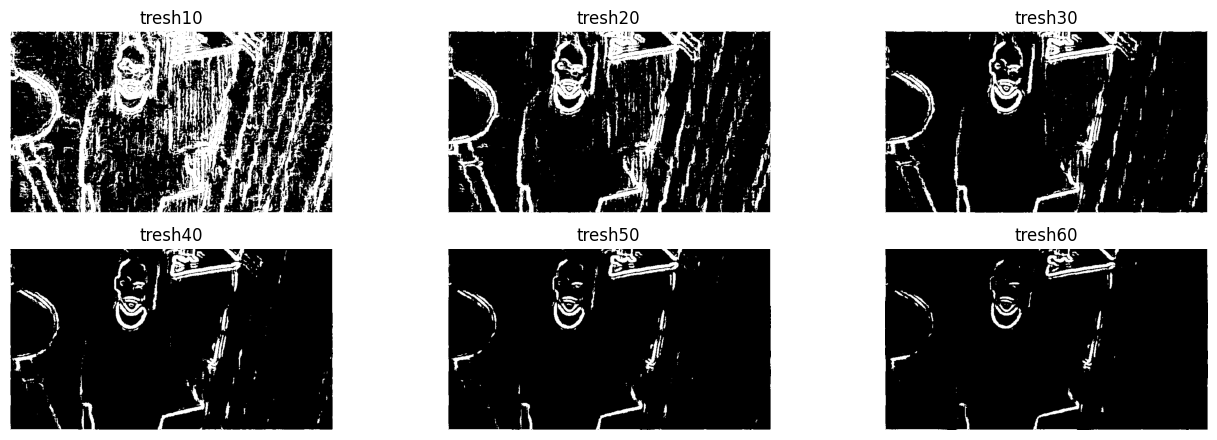

In [114]:
tresh10 = treshold_tepi(ketiganya, 10)
tresh20 = treshold_tepi(ketiganya, 20)
tresh30 = treshold_tepi(ketiganya, 30)
tresh40 = treshold_tepi(ketiganya, 40)
tresh50 = treshold_tepi(ketiganya, 50)
tresh60 = treshold_tepi(ketiganya, 60)

plt.figure(figsize=(16, 8))

plt.subplot(3, 3, 1)
plt.imshow(tresh10, cmap='gray')
plt.title("tresh10")
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(tresh20, cmap='gray')
plt.title("tresh20")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(tresh30, cmap='gray')
plt.title("tresh30")
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(tresh40, cmap='gray')
plt.title("tresh40")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(tresh50, cmap='gray')
plt.title("tresh50")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(tresh60, cmap='gray')
plt.title("tresh60")
plt.axis('off')

Jika dilihat dari citra, semakin tinggi nilai tresholdingnya tepi nya semakin hilang, karena nilainya terus di kali dengan angka 255

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

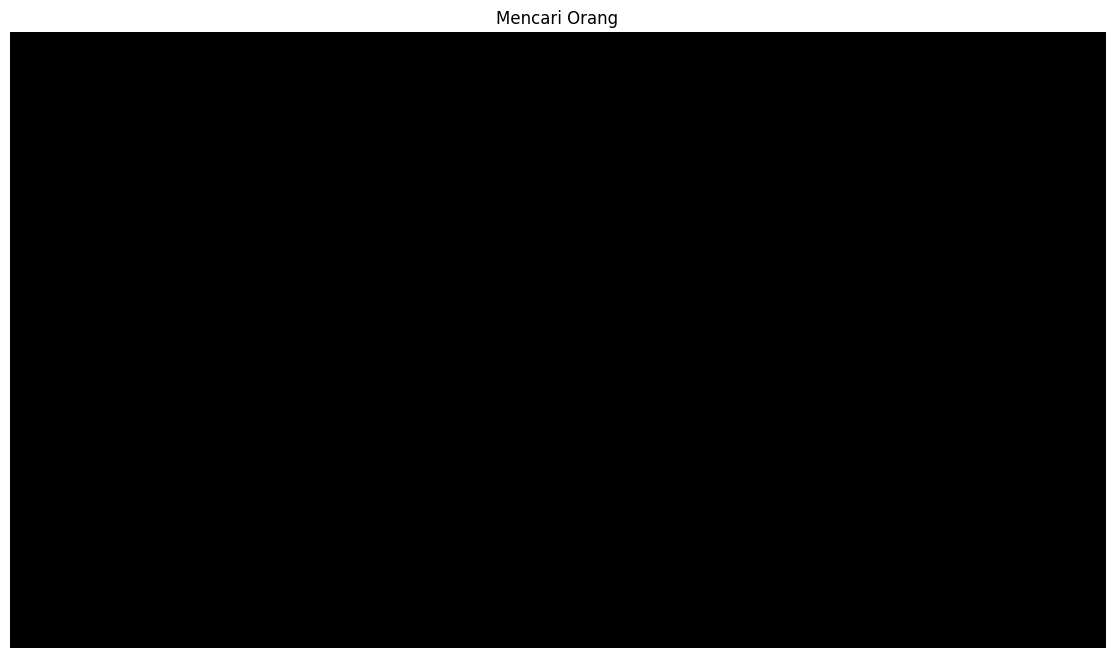

In [118]:
treshNyari = treshold_tepi(sharp, 10)

plt.figure(figsize=(16, 8))

plt.imshow(treshNyari, cmap='gray')
plt.title("Mencari Orang")
plt.axis('off')